# Task 3 — Domain Generalization on PACS

This notebook is the primary entry point. It compares the unchanged Task 2 source-only ERM checkpoint with target-free DAN-DG and SAM. Model selection uses only mean macro-F1 over Photo, Art Painting, and Cartoon validation splits.

The held-out target domain is deliberately unresolved and unopened until the explicitly marked final-evaluation section. The controlled-study values are fixed in advance and its models are trained before that boundary.


## 1. Setup and global configuration


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
import shutil
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets
from tqdm.auto import tqdm

TASK_DIR = Path.cwd().resolve()
if TASK_DIR.name != "task3":
    candidate = TASK_DIR / "task3"
    if candidate.is_dir():
        TASK_DIR = candidate.resolve()
REPO_DIR = TASK_DIR.parent
TASK2_DIR = REPO_DIR / "task2"
sys.path.insert(0, str(TASK_DIR))

from utils import (
    NUM_CLASSES,
    SOURCE_DOMAINS,
    ResNet18Adapter,
    freeze_batchnorm_running_stats,
    load_source_protocol,
    multi_kernel_mmd,
    resolve_domain_dir,
)

SEED = 6304
SOURCE_BATCH_PER_DOMAIN = 8
EVAL_BATCH_SIZE = 128
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAIN_DAN_LAMBDA = 1.0
MAIN_SAM_RHO = 0.05
CONTROLLED_DAN_LAMBDAS = (0.1, 1.0, 10.0)

RESULTS_DIR = TASK_DIR / "results"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
CURVE_DIR = RESULTS_DIR / "training_curves"
CONFUSION_DIR = RESULTS_DIR / "confusion_matrices"
CACHE_DIR = RESULTS_DIR / "cache"
for directory in (RESULTS_DIR, CHECKPOINT_DIR, CURVE_DIR, CONFUSION_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CUDA_ENABLED = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if CUDA_ENABLED and torch.cuda.is_bf16_supported() else torch.float16
torch.backends.cudnn.benchmark = True

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def amp_context():
    return torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=CUDA_ENABLED)

def make_grad_scaler():
    return torch.amp.GradScaler(
        "cuda", enabled=(CUDA_ENABLED and AMP_DTYPE == torch.float16)
    )

def make_loader(dataset, *, batch_size, shuffle=False, drop_last=False, generator=None):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        generator=generator,
        num_workers=0,
        pin_memory=CUDA_ENABLED,
    )

def train_mode_with_frozen_bn(model: nn.Module) -> None:
    model.train()
    freeze_batchnorm_running_stats(model)

def emit_figure(fig, description: str, path: Path) -> None:
    fig.tight_layout()
    print(f"Figure: {description}")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Figure: {description}")
    plt.show()
    plt.close(fig)

def json_dump(payload, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)

def safe_torch_load(path: Path, map_location=DEVICE):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

seed_everything()
print(f"Device={DEVICE}; AMP dtype={AMP_DTYPE}; seed={SEED}")


Device=cuda; AMP dtype=torch.bfloat16; seed=6304


## 2. Load and verify Task 2 source splits

Only source-domain directories are resolved here. The saved manifest is validated against file ordering, class mappings, and a complete disjoint train/validation partition.


In [2]:
PACS_ROOT = Path(os.environ.get("PACS_ROOT", TASK2_DIR / "data")).expanduser().resolve()
SPLIT_PATH = TASK2_DIR / "results" / f"pacs_splits_seed{SEED}.json"
protocol = load_source_protocol(PACS_ROOT, SPLIT_PATH, SEED)
source_train_sets = protocol["train_sets"]
source_val_sets = protocol["val_sets"]
class_to_idx = protocol["class_to_idx"]
CLASS_NAMES = [name for name, index in sorted(class_to_idx.items(), key=lambda item: item[1])]
eval_transform = protocol["eval_transform"]

print("Verified Task 2 split:", SPLIT_PATH)
print({
    domain: {"train": len(source_train_sets[domain]), "val": len(source_val_sets[domain])}
    for domain in SOURCE_DOMAINS
})
assert all("sketch" not in str(dataset.dataset.root).lower() for dataset in source_train_sets.values())
assert all("sketch" not in str(dataset.dataset.root).lower() for dataset in source_val_sets.values())


Verified Task 2 split: /mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/results/pacs_splits_seed6304.json
{'photo': {'train': 1336, 'val': 334}, 'art_painting': {'train': 1638, 'val': 410}, 'cartoon': {'train': 1875, 'val': 469}}


## 3. Shared batching, evaluation, and artifact helpers


In [3]:
class RestartingLoader:
    def __init__(self, loader: DataLoader):
        self.loader = loader
        self.iterator = iter(loader)

    def next(self):
        try:
            return next(self.iterator)
        except StopIteration:
            self.iterator = iter(self.loader)
            return next(self.iterator)

@dataclass
class SourceStreams:
    streams: Dict[str, RestartingLoader]
    steps_per_epoch: int

def make_source_streams(seed: int = SEED) -> SourceStreams:
    streams = {}
    for offset, domain in enumerate(SOURCE_DOMAINS):
        generator = torch.Generator().manual_seed(seed + offset)
        loader = make_loader(
            source_train_sets[domain],
            batch_size=SOURCE_BATCH_PER_DOMAIN,
            shuffle=True,
            drop_last=True,
            generator=generator,
        )
        streams[domain] = RestartingLoader(loader)
    steps = max(
        math.ceil(len(source_train_sets[domain]) / SOURCE_BATCH_PER_DOMAIN)
        for domain in SOURCE_DOMAINS
    )
    return SourceStreams(streams, steps)

def next_source_batch(streams: SourceStreams):
    domain_images, domain_labels = [], []
    for domain in SOURCE_DOMAINS:
        images, labels = streams.streams[domain].next()
        if images.shape[0] != SOURCE_BATCH_PER_DOMAIN:
            raise RuntimeError("A source loader violated the exact eight-example domain batch.")
        domain_images.append(
            images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        )
        domain_labels.append(labels.to(DEVICE, non_blocking=True))
    return domain_images, domain_labels

@torch.no_grad()
def evaluate_labeled(model: nn.Module, dataset: Dataset, return_arrays: bool = False):
    model.eval()
    truths, predictions, logits_all = [], [], []
    loader = make_loader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        with amp_context():
            logits, _ = model(images)
        if not torch.isfinite(logits).all():
            raise FloatingPointError("Non-finite evaluation logits.")
        truths.append(labels.numpy())
        predictions.append(logits.argmax(1).cpu().numpy())
        if return_arrays:
            logits_all.append(logits.float().cpu().numpy())
    y_true = np.concatenate(truths)
    y_pred = np.concatenate(predictions)
    result = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }
    if return_arrays:
        result.update(y_true=y_true, y_pred=y_pred, logits=np.concatenate(logits_all))
    return result

def evaluate_sources(model: nn.Module):
    metrics = {
        domain: evaluate_labeled(model, source_val_sets[domain])
        for domain in SOURCE_DOMAINS
    }
    mean_f1 = float(np.mean([metrics[domain]["macro_f1"] for domain in SOURCE_DOMAINS]))
    return metrics, mean_f1

def checkpoint_stem(name: str) -> str:
    return name.lower().replace("-", "_").replace(".", "p")

def render_training_curves(history, method_name: str, has_alignment: bool) -> None:
    frame = pd.DataFrame(history)
    columns = 2 if has_alignment else 1
    fig, axes = plt.subplots(1, columns, figsize=(10 if columns == 2 else 5, 4))
    axes = np.atleast_1d(axes)
    axes[0].plot(frame["epoch"], frame["classification_loss"], marker="o")
    axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[0].grid(alpha=0.25)
    if has_alignment:
        axes[1].plot(frame["epoch"], frame["alignment_loss"], marker="o", color="tab:orange")
        axes[1].set(xlabel="Epoch", ylabel="Unweighted pairwise MMD penalty")
        axes[1].grid(alpha=0.25)
    stem = checkpoint_stem(method_name)
    frame.to_csv(CURVE_DIR / f"{stem}.csv", index=False)
    emit_figure(
        fig,
        f"{method_name} source training curves",
        CURVE_DIR / f"{stem}.png",
    )


## 4. Unchanged Task 2 ERM baseline

The model is loaded verbatim. Its checkpoint is hashed and its metadata is copied for verification; no replacement checkpoint is written.


,accuracy,macro_f1
photo,0.967066,0.960658
art_painting,0.924390,0.930780
cartoon,0.948827,0.952666


Mean source macro-F1: 0.9480344894745243
Figure: erm_loaded_unchanged source training curves
Figure: erm_loaded_unchanged source training curves


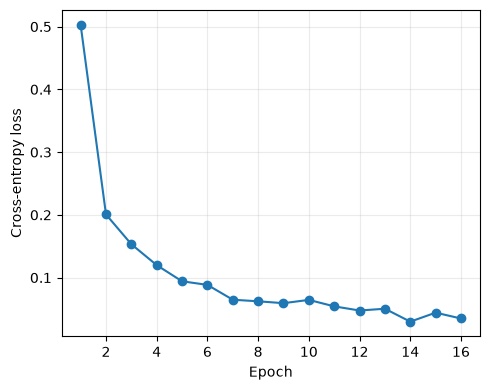

In [4]:
ERM_CHECKPOINT_PATH = TASK2_DIR / "results" / "checkpoints" / f"source_only_seed{SEED}.pt"
ERM_METADATA_PATH = ERM_CHECKPOINT_PATH.with_suffix(".json")
erm_payload = safe_torch_load(ERM_CHECKPOINT_PATH)
with ERM_METADATA_PATH.open("r", encoding="utf-8") as handle:
    erm_task2_metadata = json.load(handle)

if erm_payload["seed"] != SEED or erm_payload["class_to_idx"] != class_to_idx:
    raise ValueError("Task 2 ERM checkpoint does not match the shared PACS protocol.")
erm_model = ResNet18Adapter().to(DEVICE, memory_format=torch.channels_last)
erm_model.load_state_dict(erm_payload["model_state"])
erm_model.eval()
erm_source_metrics, erm_mean_source_f1 = evaluate_sources(erm_model)

erm_verification = {
    "source_checkpoint": str(ERM_CHECKPOINT_PATH),
    "sha256": file_sha256(ERM_CHECKPOINT_PATH),
    "unchanged": True,
    "task2_metadata": erm_task2_metadata,
    "recomputed_source_metrics": erm_source_metrics,
}
json_dump(erm_verification, RESULTS_DIR / "erm_checkpoint_metadata.json")
display(pd.DataFrame(erm_source_metrics).T)
print("Mean source macro-F1:", erm_mean_source_f1)

task2_erm_curve = TASK2_DIR / "results" / "training_curves" / "source_only.csv"
if task2_erm_curve.exists():
    erm_history = pd.read_csv(task2_erm_curve)
    render_training_curves(
        erm_history.rename(columns={"adaptation_loss": "alignment_loss"}).to_dict("records"),
        "erm_loaded_unchanged",
        has_alignment=False,
    )


## 5. DAN-DG: pairwise source-domain alignment

For each balanced batch, classification uses all three labeled domains and the alignment term is the average MMD over the three unordered source-domain pairs. The MMD implementation is imported from the factored Task 2 utility.


dan_dg | Epoch 1/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg epoch 1: source validation macro-F1=0.0507


dan_dg | Epoch 2/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg epoch 2: source validation macro-F1=0.0507


dan_dg | Epoch 3/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dan_dg epoch 4: source validation macro-F1=0.0507


dan_dg | Epoch 5/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg epoch 5: source validation macro-F1=0.0507


dan_dg | Epoch 6/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg epoch 6: source validation macro-F1=0.0507
dan_dg: early stopping after 6 epochs.
Figure: dan_dg source training curves
Figure: dan_dg source training curves


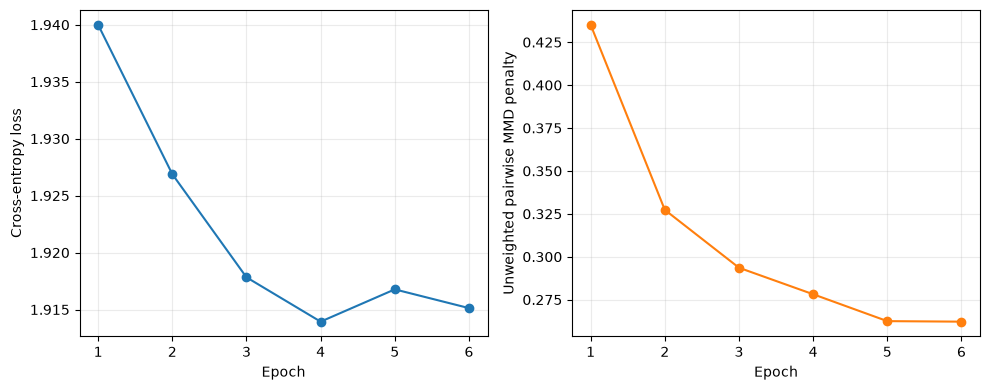

In [5]:
def train_dan_dg(lambda_dg: float, run_name: str):
    seed_everything(SEED)
    model = ResNet18Adapter().to(DEVICE, memory_format=torch.channels_last)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scaler = make_grad_scaler()
    streams = make_source_streams(SEED)
    checkpoint_path = CHECKPOINT_DIR / f"{checkpoint_stem(run_name)}_seed{SEED}.pt"
    best_f1, stale_epochs = -math.inf, 0
    history = []

    for epoch in range(MAX_EPOCHS):
        train_mode_with_frozen_bn(model)
        classification_sum, alignment_sum = 0.0, 0.0
        pbar = tqdm(
            range(streams.steps_per_epoch),
            desc=f"{run_name} | Epoch {epoch + 1}/{MAX_EPOCHS}",
            unit="batch",
            leave=True,
        )
        for batch_index in pbar:
            images_by_domain, labels_by_domain = next_source_batch(streams)
            images = torch.cat(images_by_domain)
            labels = torch.cat(labels_by_domain)
            optimizer.zero_grad(set_to_none=True)
            with amp_context():
                logits, features = model(images)
                classification_loss = F.cross_entropy(logits, labels)
                feature_chunks = features.split(SOURCE_BATCH_PER_DOMAIN)
                pairwise_mmd = (
                    multi_kernel_mmd(feature_chunks[0], feature_chunks[1])
                    + multi_kernel_mmd(feature_chunks[0], feature_chunks[2])
                    + multi_kernel_mmd(feature_chunks[1], feature_chunks[2])
                ) / 3.0
                loss = classification_loss + lambda_dg * pairwise_mmd
            if not torch.isfinite(loss):
                raise FloatingPointError(f"{run_name} produced a non-finite loss.")
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            classification_sum += float(classification_loss.detach())
            alignment_sum += float(pairwise_mmd.detach())
            completed = batch_index + 1
            pbar.set_postfix(
                cls=f"{classification_sum / completed:.4f}",
                mmd=f"{alignment_sum / completed:.4f}",
            )

        source_metrics, mean_source_f1 = evaluate_sources(model)
        record = {
            "epoch": epoch + 1,
            "classification_loss": classification_sum / streams.steps_per_epoch,
            "alignment_loss": alignment_sum / streams.steps_per_epoch,
            "mean_source_val_f1": mean_source_f1,
        }
        history.append(record)
        tqdm.write(
            f"{run_name} epoch {epoch + 1}: source validation macro-F1={mean_source_f1:.4f}"
        )
        if mean_source_f1 > best_f1:
            best_f1, stale_epochs = mean_source_f1, 0
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "method": "dan_dg",
                    "run_name": run_name,
                    "lambda_dg": lambda_dg,
                    "epoch": epoch + 1,
                    "seed": SEED,
                    "class_to_idx": class_to_idx,
                    "source_val": source_metrics,
                    "mean_source_val_macro_f1": mean_source_f1,
                    "amp_dtype": str(AMP_DTYPE),
                },
                checkpoint_path,
            )
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                tqdm.write(f"{run_name}: early stopping after {epoch + 1} epochs.")
                break

    saved = safe_torch_load(checkpoint_path)
    model.load_state_dict(saved["model_state"])
    model.eval()
    render_training_curves(history, run_name, has_alignment=True)
    return {
        "model": model,
        "checkpoint": saved,
        "checkpoint_path": checkpoint_path,
        "history": history,
    }

dan_run = train_dan_dg(MAIN_DAN_LAMBDA, "dan_dg")


## 6. SAM: parameter-space stability

SAM uses two mixed-precision forward/backward passes on the same balanced source batch. Gradients from the first pass define a normalized radius-0.05 ascent perturbation. Parameters are restored before AdamW applies the second-pass gradient, and the scaler is updated exactly once per real optimizer update.


sam | Epoch 1/30:   0%|          | 0/235 [00:00<?, ?batch/s]

sam epoch 1: source validation macro-F1=0.8784


sam | Epoch 2/30:   0%|          | 0/235 [00:00<?, ?batch/s]

sam epoch 2: source validation macro-F1=0.8726


sam | Epoch 3/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

sam epoch 9: source validation macro-F1=0.9533


sam | Epoch 10/30:   0%|          | 0/235 [00:00<?, ?batch/s]

sam epoch 10: source validation macro-F1=0.9408


sam | Epoch 11/30:   0%|          | 0/235 [00:00<?, ?batch/s]

sam epoch 11: source validation macro-F1=0.9494
sam: early stopping after 11 epochs.
Figure: sam source training curves
Figure: sam source training curves


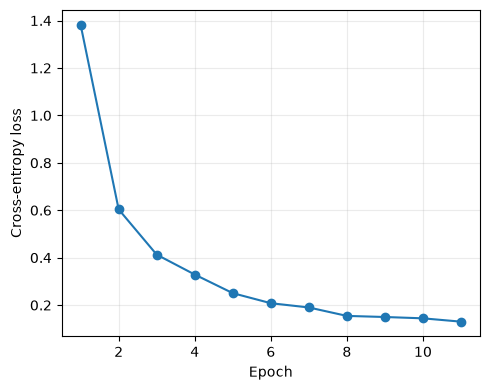

In [6]:
class SAMOptimizer:
    def __init__(self, parameters, base_optimizer, rho: float):
        self.parameters = list(parameters)
        self.base_optimizer = base_optimizer
        self.rho = rho
        self.perturbations = {}

    @torch.no_grad()
    def first_step(self, grad_scale: float = 1.0, zero_grad: bool = True):
        gradients = [
            parameter.grad.detach().float() / grad_scale
            for parameter in self.parameters
            if parameter.grad is not None
        ]
        if not gradients:
            raise RuntimeError("SAM received no gradients on its first pass.")
        if not all(torch.isfinite(gradient).all() for gradient in gradients):
            raise FloatingPointError("SAM first-pass gradients are non-finite.")
        grad_norm = torch.linalg.vector_norm(
            torch.stack([torch.linalg.vector_norm(gradient, ord=2) for gradient in gradients]),
            ord=2,
        )
        scale = self.rho / (grad_norm + 1e-12)
        self.perturbations.clear()
        for parameter in self.parameters:
            if parameter.grad is None:
                continue
            perturbation = (parameter.grad.detach() / grad_scale) * scale.to(parameter)
            parameter.add_(perturbation)
            self.perturbations[parameter] = perturbation
        if zero_grad:
            self.base_optimizer.zero_grad(set_to_none=True)

    @torch.no_grad()
    def restore(self):
        for parameter, perturbation in self.perturbations.items():
            parameter.sub_(perturbation)
        self.perturbations.clear()

    def second_step(self, scaler):
        self.restore()
        scaler.step(self.base_optimizer)
        scaler.update()
        self.base_optimizer.zero_grad(set_to_none=True)

def train_sam(rho: float = MAIN_SAM_RHO, run_name: str = "sam"):
    seed_everything(SEED)
    model = ResNet18Adapter().to(DEVICE, memory_format=torch.channels_last)
    base_optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    sam = SAMOptimizer(model.parameters(), base_optimizer, rho=rho)
    scaler = make_grad_scaler()
    streams = make_source_streams(SEED)
    checkpoint_path = CHECKPOINT_DIR / f"{checkpoint_stem(run_name)}_seed{SEED}.pt"
    best_f1, stale_epochs = -math.inf, 0
    history = []

    for epoch in range(MAX_EPOCHS):
        train_mode_with_frozen_bn(model)
        classification_sum = 0.0
        pbar = tqdm(
            range(streams.steps_per_epoch),
            desc=f"{run_name} | Epoch {epoch + 1}/{MAX_EPOCHS}",
            unit="batch",
            leave=True,
        )
        for batch_index in pbar:
            images_by_domain, labels_by_domain = next_source_batch(streams)
            images = torch.cat(images_by_domain)
            labels = torch.cat(labels_by_domain)
            base_optimizer.zero_grad(set_to_none=True)

            with amp_context():
                first_logits, _ = model(images)
                first_loss = F.cross_entropy(first_logits, labels)
            if not torch.isfinite(first_loss):
                raise FloatingPointError("SAM first-pass loss is non-finite.")
            scaler.scale(first_loss).backward()
            sam.first_step(grad_scale=float(scaler.get_scale()), zero_grad=True)

            try:
                with amp_context():
                    second_logits, _ = model(images)
                    second_loss = F.cross_entropy(second_logits, labels)
                if not torch.isfinite(second_loss):
                    raise FloatingPointError("SAM second-pass loss is non-finite.")
                scaler.scale(second_loss).backward()
                sam.second_step(scaler)
            except Exception:
                sam.restore()
                raise

            classification_sum += float(second_loss.detach())
            completed = batch_index + 1
            pbar.set_postfix(loss=f"{classification_sum / completed:.4f}")

        source_metrics, mean_source_f1 = evaluate_sources(model)
        record = {
            "epoch": epoch + 1,
            "classification_loss": classification_sum / streams.steps_per_epoch,
            "mean_source_val_f1": mean_source_f1,
        }
        history.append(record)
        tqdm.write(
            f"{run_name} epoch {epoch + 1}: source validation macro-F1={mean_source_f1:.4f}"
        )
        if mean_source_f1 > best_f1:
            best_f1, stale_epochs = mean_source_f1, 0
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "method": "sam",
                    "run_name": run_name,
                    "rho": rho,
                    "epoch": epoch + 1,
                    "seed": SEED,
                    "class_to_idx": class_to_idx,
                    "source_val": source_metrics,
                    "mean_source_val_macro_f1": mean_source_f1,
                    "amp_dtype": str(AMP_DTYPE),
                },
                checkpoint_path,
            )
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                tqdm.write(f"{run_name}: early stopping after {epoch + 1} epochs.")
                break

    saved = safe_torch_load(checkpoint_path)
    model.load_state_dict(saved["model_state"])
    model.eval()
    render_training_curves(history, run_name, has_alignment=False)
    return {
        "model": model,
        "checkpoint": saved,
        "checkpoint_path": checkpoint_path,
        "history": history,
    }

sam_run = train_sam()


## 7. Controlled design study: DAN-DG alignment weight

Hypothesis fixed before running: increasing lambda from 0.1 to 1 should reduce source-domain separability, with a modest source-performance cost and potentially better held-out generalization. Lambda 10 may over-align marginal distributions, further lowering separability while harming class discrimination and held-out performance. These runs are descriptive: lambda 1 remains the main DAN-DG setting regardless of any held-out result.


dan_dg_lambda_0.1 | Epoch 1/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_0.1 epoch 1: source validation macro-F1=0.9114


dan_dg_lambda_0.1 | Epoch 2/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_0.1 epoch 2: source validation macro-F1=0.8807


dan_dg_lambda_0.1 | Epoch 3/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dan_dg_lambda_0.1 epoch 15: source validation macro-F1=0.9254


dan_dg_lambda_0.1 | Epoch 16/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_0.1 epoch 16: source validation macro-F1=0.9412


dan_dg_lambda_0.1 | Epoch 17/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_0.1 epoch 17: source validation macro-F1=0.9422
dan_dg_lambda_0.1: early stopping after 17 epochs.
Figure: dan_dg_lambda_0.1 source training curves
Figure: dan_dg_lambda_0.1 source training curves


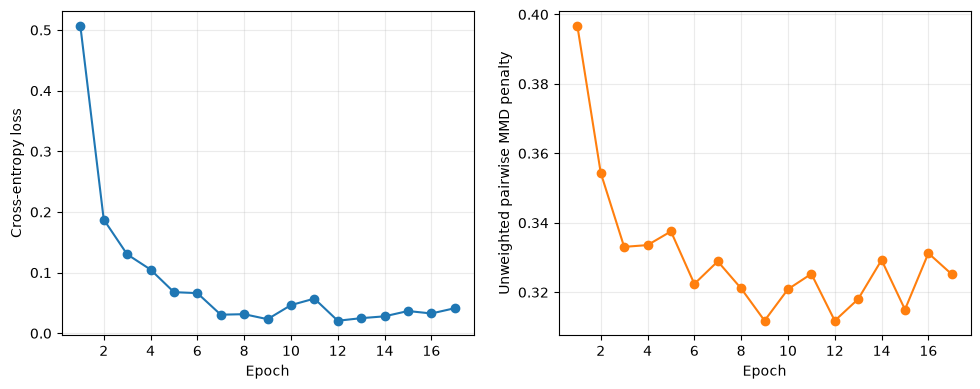

dan_dg_lambda_10 | Epoch 1/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_10 epoch 1: source validation macro-F1=0.0361


dan_dg_lambda_10 | Epoch 2/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_10 epoch 2: source validation macro-F1=0.0507


dan_dg_lambda_10 | Epoch 3/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dan_dg_lambda_10 epoch 5: source validation macro-F1=0.0507


dan_dg_lambda_10 | Epoch 6/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_10 epoch 6: source validation macro-F1=0.0507


dan_dg_lambda_10 | Epoch 7/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_dg_lambda_10 epoch 7: source validation macro-F1=0.0507
dan_dg_lambda_10: early stopping after 7 epochs.
Figure: dan_dg_lambda_10 source training curves
Figure: dan_dg_lambda_10 source training curves


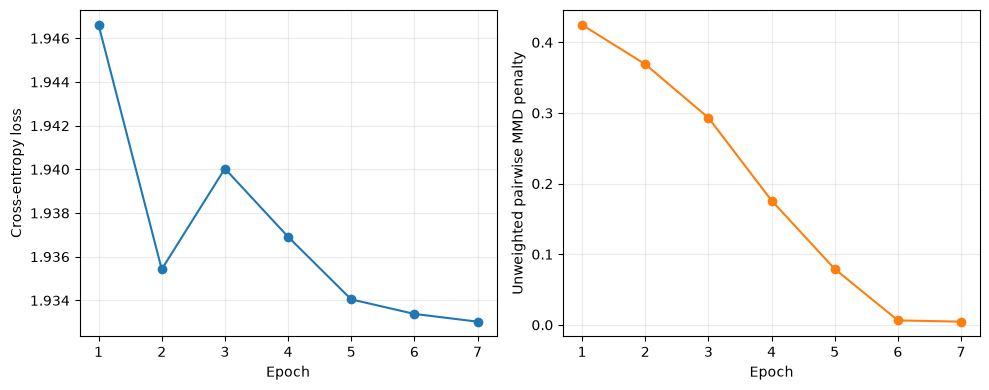

In [7]:
controlled_runs = {1.0: dan_run}
controlled_runs[0.1] = train_dan_dg(0.1, "dan_dg_lambda_0.1")
controlled_runs[10.0] = train_dan_dg(10.0, "dan_dg_lambda_10")


## 8. Source-only diagnostics

The three-way probe uses equal feature counts from each source validation domain and a seeded 70/30 split. Chance accuracy is 33.3%. Lower probe accuracy indicates less domain information, but does not imply better class separation or held-out recognition.

The sharpness value is a standardized local one-step proxy on one fixed validation batch containing 32 examples from each source domain. It is not evidence of global flatness.


In [8]:
@torch.no_grad()
def extract_features(model: nn.Module, dataset: Dataset):
    model.eval()
    features, labels = [], []
    loader = make_loader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)
    for images, batch_labels in loader:
        images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        with amp_context():
            _, batch_features = model(images)
        batch_features = batch_features.float()
        if not torch.isfinite(batch_features).all():
            raise FloatingPointError("Non-finite cached features.")
        features.append(batch_features.cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(features), np.concatenate(labels)

def checkpoint_signature(path: Path) -> str:
    return file_sha256(path)[:12]

def cached_source_features(method_name: str, model: nn.Module, checkpoint_path: Path):
    cache_path = (
        CACHE_DIR
        / f"{checkpoint_stem(method_name)}_{checkpoint_signature(checkpoint_path)}_source_features.npz"
    )
    if cache_path.exists():
        cache = np.load(cache_path)
        return {domain: cache[domain] for domain in SOURCE_DOMAINS}
    features = {
        domain: extract_features(model, source_val_sets[domain])[0]
        for domain in SOURCE_DOMAINS
    }
    np.savez_compressed(cache_path, **features)
    return features

def source_domain_separability(method_name: str, model: nn.Module, checkpoint_path: Path):
    features = cached_source_features(method_name, model, checkpoint_path)
    balanced_count = min(len(features[domain]) for domain in SOURCE_DOMAINS)
    rng = np.random.default_rng(SEED)
    x_parts, y_parts = [], []
    for domain_index, domain in enumerate(SOURCE_DOMAINS):
        chosen = rng.choice(len(features[domain]), size=balanced_count, replace=False)
        x_parts.append(features[domain][chosen])
        y_parts.append(np.full(balanced_count, domain_index, dtype=int))
    x = np.concatenate(x_parts)
    y = np.concatenate(y_parts)
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.30, random_state=SEED, stratify=y
    )
    probe = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)
    probe.fit(x_train, y_train)
    return float(accuracy_score(y_test, probe.predict(x_test)))

SHARPNESS_INDEX_PATH = CACHE_DIR / f"sharpness_source_indices_seed{SEED}.json"
if SHARPNESS_INDEX_PATH.exists():
    with SHARPNESS_INDEX_PATH.open("r", encoding="utf-8") as handle:
        sharpness_indices = json.load(handle)
else:
    rng = np.random.default_rng(SEED)
    sharpness_indices = {
        domain: sorted(
            map(int, rng.choice(len(source_val_sets[domain]), size=32, replace=False))
        )
        for domain in SOURCE_DOMAINS
    }
    json_dump(sharpness_indices, SHARPNESS_INDEX_PATH)

def fixed_sharpness_batch():
    image_parts, label_parts = [], []
    for domain in SOURCE_DOMAINS:
        subset = Subset(source_val_sets[domain], sharpness_indices[domain])
        loader = make_loader(subset, batch_size=32, shuffle=False)
        images, labels = next(iter(loader))
        image_parts.append(images)
        label_parts.append(labels)
    images = torch.cat(image_parts).to(
        DEVICE, non_blocking=True, memory_format=torch.channels_last
    )
    labels = torch.cat(label_parts).to(DEVICE, non_blocking=True)
    return images, labels

sharpness_images, sharpness_labels = fixed_sharpness_batch()

def local_sharpness(method_name: str, model: nn.Module, checkpoint_path: Path, rho=0.05):
    cache_path = (
        CACHE_DIR
        / f"{checkpoint_stem(method_name)}_{checkpoint_signature(checkpoint_path)}_sharpness.json"
    )
    if cache_path.exists():
        with cache_path.open("r", encoding="utf-8") as handle:
            return float(json.load(handle)["delta_sharp"])

    model.eval()
    model.zero_grad(set_to_none=True)
    scaler = make_grad_scaler()
    with amp_context():
        base_logits, _ = model(sharpness_images)
        base_loss = F.cross_entropy(base_logits, sharpness_labels)
    scaler.scale(base_loss).backward()
    grad_scale = float(scaler.get_scale())
    parameters = [parameter for parameter in model.parameters() if parameter.grad is not None]
    gradients = [parameter.grad.detach().float() / grad_scale for parameter in parameters]
    if not all(torch.isfinite(gradient).all() for gradient in gradients):
        raise FloatingPointError("Non-finite gradient in sharpness diagnostic.")
    grad_norm = torch.linalg.vector_norm(
        torch.stack([torch.linalg.vector_norm(gradient, ord=2) for gradient in gradients]),
        ord=2,
    )
    perturbations = []
    with torch.no_grad():
        scale = rho / (grad_norm + 1e-12)
        for parameter in parameters:
            perturbation = (parameter.grad.detach() / grad_scale) * scale.to(parameter)
            parameter.add_(perturbation)
            perturbations.append((parameter, perturbation))
    try:
        with torch.no_grad(), amp_context():
            perturbed_logits, _ = model(sharpness_images)
            perturbed_loss = F.cross_entropy(perturbed_logits, sharpness_labels)
    finally:
        with torch.no_grad():
            for parameter, perturbation in perturbations:
                parameter.sub_(perturbation)
        model.zero_grad(set_to_none=True)
    delta = float((perturbed_loss - base_loss).detach())
    json_dump({"rho": rho, "delta_sharp": delta}, cache_path)
    return delta

main_runs = {
    "ERM": {
        "model": erm_model,
        "checkpoint_path": ERM_CHECKPOINT_PATH,
    },
    "DAN-DG": dan_run,
    "SAM": sam_run,
}

separability_rows, sharpness_rows = [], []
for method_name, run in main_runs.items():
    separability_rows.append({
        "method": method_name,
        "probe_accuracy": source_domain_separability(
            method_name, run["model"], run["checkpoint_path"]
        ),
        "chance_accuracy": 1.0 / 3.0,
    })
    sharpness_rows.append({
        "method": method_name,
        "rho": 0.05,
        "delta_sharp": local_sharpness(
            method_name, run["model"], run["checkpoint_path"], rho=0.05
        ),
    })

source_domain_separability_table = pd.DataFrame(separability_rows)
sharpness_proxy_table = pd.DataFrame(sharpness_rows)
source_domain_separability_table.to_csv(
    RESULTS_DIR / "source_domain_separability.csv", index=False
)
sharpness_proxy_table.to_csv(RESULTS_DIR / "sharpness_proxy.csv", index=False)
display(source_domain_separability_table)
display(sharpness_proxy_table)

controlled_source_rows = []
for lambda_dg, run in sorted(controlled_runs.items()):
    source_metrics, mean_source_f1 = evaluate_sources(run["model"])
    controlled_source_rows.append({
        "lambda_dg": lambda_dg,
        "mean_source_acc": float(np.mean([
            source_metrics[domain]["accuracy"] for domain in SOURCE_DOMAINS
        ])),
        "mean_source_f1": mean_source_f1,
        "source_domain_separability": source_domain_separability(
            f"dan_dg_lambda_{lambda_dg}", run["model"], run["checkpoint_path"]
        ),
    })
controlled_source_table = pd.DataFrame(controlled_source_rows)
display(controlled_source_table)


,method,probe_accuracy,chance_accuracy
0,ERM,0.850498,0.333333
1,DAN-DG,0.302326,0.333333
2,SAM,0.873754,0.333333


,method,rho,delta_sharp
0,ERM,0.05,0.383121
1,DAN-DG,0.05,0.032471
2,SAM,0.05,0.133222


,lambda_dg,mean_source_acc,mean_source_f1,source_domain_separability
0,0.1,0.950821,0.951836,0.760797
1,1.0,0.216568,0.050670,0.302326
2,10.0,0.216568,0.050670,0.332226


## 9. Freeze all Task 3 decisions

At this boundary, architectures, losses, main settings, all source-selected checkpoints, and the complete controlled-study grid are frozen. No held-out image or label has been loaded above. The following cell is the first code path that resolves and opens the held-out domain.


In [9]:
FROZEN_CONFIGURATION = {
    "seed": SEED,
    "selection_metric": "mean source validation macro-F1",
    "main_dan_lambda": MAIN_DAN_LAMBDA,
    "main_sam_rho": MAIN_SAM_RHO,
    "controlled_dan_lambdas": list(CONTROLLED_DAN_LAMBDAS),
    "main_checkpoints": {
        method: str(run["checkpoint_path"]) for method, run in main_runs.items()
    },
}
json_dump(FROZEN_CONFIGURATION, RESULTS_DIR / "frozen_configuration_before_target.json")
print("Task 3 decisions frozen:", FROZEN_CONFIGURATION)


Task 3 decisions frozen: {'seed': 6304, 'selection_metric': 'mean source validation macro-F1', 'main_dan_lambda': 1.0, 'main_sam_rho': 0.05, 'controlled_dan_lambdas': [0.1, 1.0, 10.0], 'main_checkpoints': {'ERM': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/results/checkpoints/source_only_seed6304.pt', 'DAN-DG': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task3/results/checkpoints/dan_dg_seed6304.pt', 'SAM': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task3/results/checkpoints/sam_seed6304.pt'}}


## 10. Final held-out evaluation — first target-data access

This is intentionally the first cell that resolves or constructs the held-out dataset. Its labels are used only for final reporting, per-class analysis, failure examples, and contextual comparison to Task 2 DAN.


In [10]:
TARGET_DOMAIN = "sketch"
target_dir = resolve_domain_dir(PACS_ROOT, TARGET_DOMAIN)
target_eval_set = datasets.ImageFolder(target_dir, transform=eval_transform)
if target_eval_set.class_to_idx != class_to_idx:
    raise ValueError("Held-out class mapping differs from the source protocol.")
if len(target_eval_set) != 3929:
    raise ValueError(f"Expected 3929 held-out images, found {len(target_eval_set)}.")

main_rows = []
target_outputs = {}
for method_name, run in main_runs.items():
    source_metrics, _ = evaluate_sources(run["model"])
    target_metrics = evaluate_labeled(run["model"], target_eval_set, return_arrays=True)
    target_outputs[method_name] = target_metrics
    row = {"method": method_name}
    for domain in SOURCE_DOMAINS:
        row[f"{domain}_acc"] = source_metrics[domain]["accuracy"]
        row[f"{domain}_f1"] = source_metrics[domain]["macro_f1"]
    row["mean_source_acc"] = float(np.mean([
        source_metrics[domain]["accuracy"] for domain in SOURCE_DOMAINS
    ]))
    row["mean_source_f1"] = float(np.mean([
        source_metrics[domain]["macro_f1"] for domain in SOURCE_DOMAINS
    ]))
    row["worst_source_acc"] = float(min(
        source_metrics[domain]["accuracy"] for domain in SOURCE_DOMAINS
    ))
    row["worst_source_f1"] = float(min(
        source_metrics[domain]["macro_f1"] for domain in SOURCE_DOMAINS
    ))
    row["sketch_acc"] = target_metrics["accuracy"]
    row["sketch_f1"] = target_metrics["macro_f1"]
    main_rows.append(row)

main_comparison = pd.DataFrame(main_rows)
erm_sketch_acc = float(
    main_comparison.loc[main_comparison["method"] == "ERM", "sketch_acc"].iloc[0]
)
main_comparison["sketch_acc_delta_vs_erm"] = (
    main_comparison["sketch_acc"] - erm_sketch_acc
)
main_comparison.to_csv(RESULTS_DIR / "main_comparison_table.csv", index=False)
display(main_comparison)


,method,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_source_acc,mean_source_f1,worst_source_acc,worst_source_f1,sketch_acc,sketch_f1,sketch_acc_delta_vs_erm
0,ERM,0.967066,0.960658,0.924390,0.930780,0.948827,0.952666,0.946761,0.948034,0.924390,0.930780,0.701196,0.692346,0.000000
1,DAN-DG,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.050670,0.172708,0.042078,0.040723,0.011180,-0.660473
2,SAM,0.979042,0.974864,0.926829,0.926488,0.957356,0.962934,0.954409,0.954762,0.926829,0.926488,0.695088,0.708349,-0.006108


### Per-class held-out analysis, confusions, and Task 2 context


,method,class,accuracy,support,delta_vs_erm,dominant_confusion
0,ERM,dog,0.598446,772,0.000000,elephant (150)
1,ERM,elephant,0.817568,740,0.000000,dog (96)
2,ERM,giraffe,0.523240,753,0.000000,dog (122)
3,ERM,guitar,0.919408,608,0.000000,elephant (37)
4,ERM,horse,0.692402,816,0.000000,dog (139)
5,ERM,house,0.537500,80,0.000000,elephant (19)
6,ERM,person,0.793750,160,0.000000,elephant (19)
7,DAN-DG,dog,0.000000,772,-0.598446,person (772)
8,DAN-DG,elephant,0.000000,740,-0.817568,person (740)
9,DAN-DG,giraffe,0.000000,753,-0.523240,person (753)


DAN-DG: largest improvement person (+0.206); largest degradation guitar (-0.919); dominant degraded-class confusion person (608).
SAM: largest improvement house (+0.312); largest degradation dog (-0.347); dominant degraded-class confusion elephant (362).
Task2-DAN: largest improvement person (+0.206); largest degradation guitar (-0.919); dominant degraded-class confusion person (608).
Figure: held-out confusion matrix for ERM
Figure: held-out confusion matrix for ERM


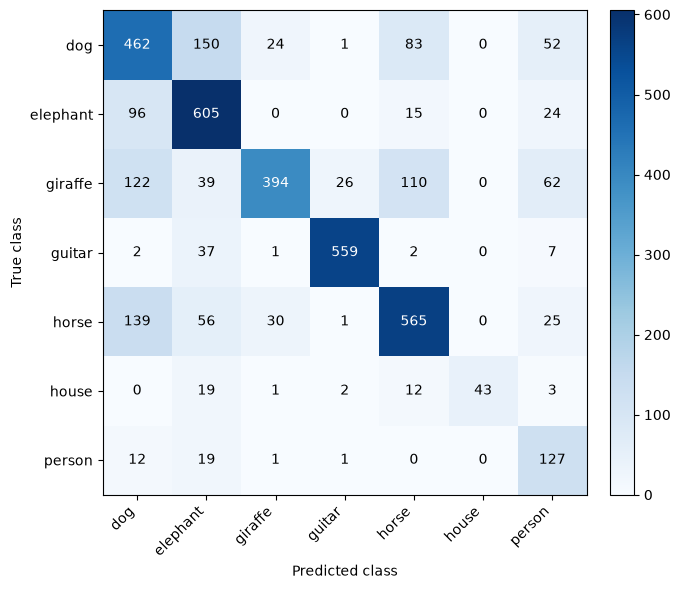

Figure: held-out confusion matrix for DAN-DG
Figure: held-out confusion matrix for DAN-DG


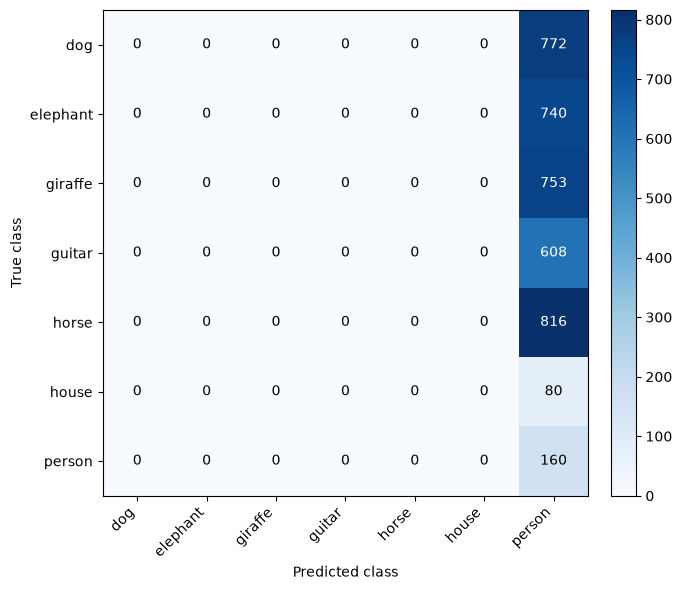

Figure: held-out confusion matrix for SAM
Figure: held-out confusion matrix for SAM


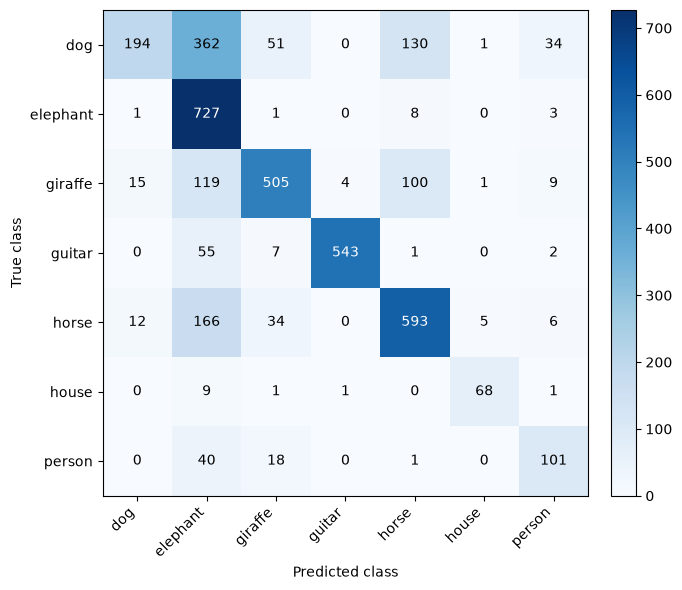

In [11]:
task2_dan_path = TASK2_DIR / "results" / "checkpoints" / f"dan_seed{SEED}.pt"
task2_dan_payload = safe_torch_load(task2_dan_path)
task2_dan_model = ResNet18Adapter().to(DEVICE, memory_format=torch.channels_last)
task2_dan_model.load_state_dict(task2_dan_payload["model_state"])
task2_dan_model.eval()
target_outputs["Task2-DAN"] = evaluate_labeled(
    task2_dan_model, target_eval_set, return_arrays=True
)

def dominant_confusion(y_true, y_pred, class_index: int):
    mask = y_true == class_index
    wrong = y_pred[mask & (y_pred != class_index)]
    if len(wrong) == 0:
        return "none"
    counts = np.bincount(wrong, minlength=NUM_CLASSES)
    predicted = int(counts.argmax())
    return f"{CLASS_NAMES[predicted]} ({int(counts[predicted])})"

baseline_output = target_outputs["ERM"]
baseline_class_accuracy = {}
for class_index in range(NUM_CLASSES):
    mask = baseline_output["y_true"] == class_index
    baseline_class_accuracy[class_index] = float(
        (baseline_output["y_pred"][mask] == class_index).mean()
    )

per_class_rows = []
for method_name, output in target_outputs.items():
    for class_index, class_name in enumerate(CLASS_NAMES):
        mask = output["y_true"] == class_index
        accuracy = float((output["y_pred"][mask] == class_index).mean())
        per_class_rows.append({
            "method": method_name,
            "class": class_name,
            "accuracy": accuracy,
            "support": int(mask.sum()),
            "delta_vs_erm": accuracy - baseline_class_accuracy[class_index],
            "dominant_confusion": dominant_confusion(
                output["y_true"], output["y_pred"], class_index
            ),
        })

per_class_sketch = pd.DataFrame(per_class_rows)
per_class_sketch.to_csv(RESULTS_DIR / "per_class_sketch_accuracy.csv", index=False)
display(per_class_sketch)

for method_name in ("DAN-DG", "SAM", "Task2-DAN"):
    subset = per_class_sketch[per_class_sketch["method"] == method_name]
    best = subset.loc[subset["delta_vs_erm"].idxmax()]
    worst = subset.loc[subset["delta_vs_erm"].idxmin()]
    print(
        f"{method_name}: largest improvement {best['class']} "
        f"({best['delta_vs_erm']:+.3f}); largest degradation {worst['class']} "
        f"({worst['delta_vs_erm']:+.3f}); dominant degraded-class confusion "
        f"{worst['dominant_confusion']}."
    )

failure_rows = []
for method_name, output in target_outputs.items():
    probabilities = torch.from_numpy(output["logits"]).softmax(1).numpy()
    wrong_indices = np.flatnonzero(output["y_pred"] != output["y_true"])
    ranked = wrong_indices[
        np.argsort(probabilities[wrong_indices].max(axis=1))[::-1]
    ][:12]
    for index in ranked:
        failure_rows.append({
            "method": method_name,
            "relative_path": str(Path(target_eval_set.samples[index][0]).relative_to(target_dir)),
            "true_class": CLASS_NAMES[int(output["y_true"][index])],
            "predicted_class": CLASS_NAMES[int(output["y_pred"][index])],
            "predicted_confidence": float(probabilities[index].max()),
        })
pd.DataFrame(failure_rows).to_csv(
    RESULTS_DIR / "sketch_failure_examples.csv", index=False
)

for method_name in ("ERM", "DAN-DG", "SAM"):
    output = target_outputs[method_name]
    matrix = confusion_matrix(
        output["y_true"], output["y_pred"], labels=np.arange(NUM_CLASSES)
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(np.arange(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(np.arange(NUM_CLASSES), CLASS_NAMES)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    for row_index in range(NUM_CLASSES):
        for column_index in range(NUM_CLASSES):
            ax.text(
                column_index,
                row_index,
                int(matrix[row_index, column_index]),
                ha="center",
                va="center",
                color="white" if matrix[row_index, column_index] > matrix.max() / 2 else "black",
            )
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    emit_figure(
        fig,
        f"held-out confusion matrix for {method_name}",
        CONFUSION_DIR / f"{checkpoint_stem(method_name)}.png",
    )


## 11. Controlled-study final reporting and summary

Held-out metrics are appended only now. They do not select or replace the lambda-1 main configuration.


,lambda_dg,mean_source_acc,mean_source_f1,source_domain_separability,sketch_acc,sketch_f1
0,0.1,0.950821,0.951836,0.760797,0.675490,0.69326
1,1.0,0.216568,0.050670,0.302326,0.040723,0.01118
2,10.0,0.216568,0.050670,0.332226,0.040723,0.01118


Figure: controlled DAN-DG alignment-weight study
Figure: controlled DAN-DG alignment-weight study


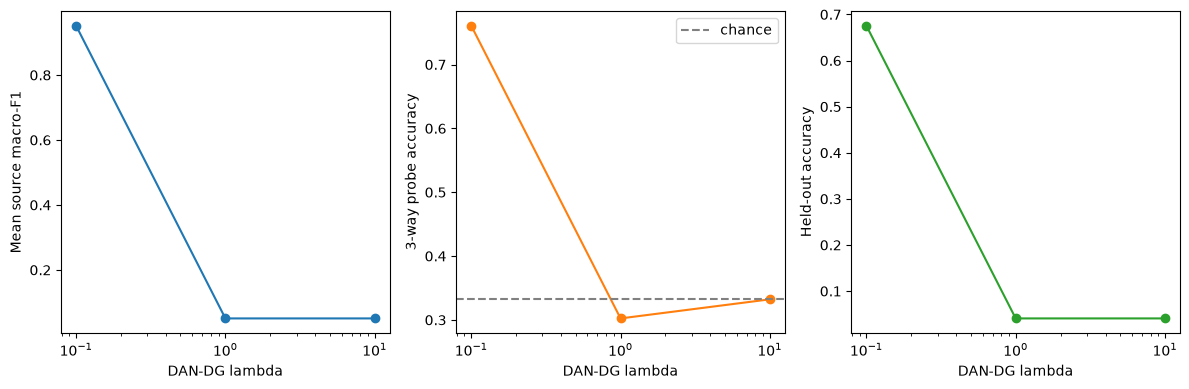

All required Task 3 artifacts are present.
Interpretation guardrail: lower source-domain probe accuracy alone does not establish better class separation or held-out performance; the sharpness measurement is a local one-step proxy, not proof of global flatness.


In [12]:
controlled_rows = []
for source_row, (lambda_dg, run) in zip(
    controlled_source_rows, sorted(controlled_runs.items())
):
    target_metrics = evaluate_labeled(run["model"], target_eval_set)
    controlled_rows.append({
        **source_row,
        "sketch_acc": target_metrics["accuracy"],
        "sketch_f1": target_metrics["macro_f1"],
    })
controlled_study = pd.DataFrame(controlled_rows).sort_values("lambda_dg")
controlled_study.to_csv(RESULTS_DIR / "controlled_study_results.csv", index=False)
display(controlled_study)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
axes[0].plot(controlled_study["lambda_dg"], controlled_study["mean_source_f1"], marker="o")
axes[0].set(xlabel="DAN-DG lambda", ylabel="Mean source macro-F1", xscale="log")
axes[1].plot(
    controlled_study["lambda_dg"],
    controlled_study["source_domain_separability"],
    marker="o",
    color="tab:orange",
)
axes[1].axhline(1.0 / 3.0, color="gray", linestyle="--", label="chance")
axes[1].set(xlabel="DAN-DG lambda", ylabel="3-way probe accuracy", xscale="log")
axes[1].legend()
axes[2].plot(
    controlled_study["lambda_dg"],
    controlled_study["sketch_acc"],
    marker="o",
    color="tab:green",
)
axes[2].set(xlabel="DAN-DG lambda", ylabel="Held-out accuracy", xscale="log")
emit_figure(
    fig,
    "controlled DAN-DG alignment-weight study",
    RESULTS_DIR / "controlled_study.png",
)

required_artifacts = [
    RESULTS_DIR / "erm_checkpoint_metadata.json",
    CHECKPOINT_DIR / f"dan_dg_seed{SEED}.pt",
    CHECKPOINT_DIR / f"sam_seed{SEED}.pt",
    RESULTS_DIR / "main_comparison_table.csv",
    RESULTS_DIR / "source_domain_separability.csv",
    RESULTS_DIR / "sharpness_proxy.csv",
    RESULTS_DIR / "per_class_sketch_accuracy.csv",
    RESULTS_DIR / "sketch_failure_examples.csv",
    RESULTS_DIR / "controlled_study_results.csv",
    RESULTS_DIR / "controlled_study.png",
]
missing = [str(path) for path in required_artifacts if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts: " + ", ".join(missing))
print("All required Task 3 artifacts are present.")
print(
    "Interpretation guardrail: lower source-domain probe accuracy alone does not "
    "establish better class separation or held-out performance; the sharpness "
    "measurement is a local one-step proxy, not proof of global flatness."
)
